# NinaPro DB5 Exercise A 完整动作序列数据准备

本 Notebook 将每一次完整动作作为一个训练样本，不使用滑动窗口。每个样本包含同一名受试者、同一动作、同一次重复的全部有效 sEMG 采样点。

由于修正后的实际动作长度不同，输出采用紧凑的变长序列格式：所有序列连续保存在 `X` 中，并通过 `offsets` 和 `lengths` 取回单个完整动作。这样不会截断动作，也不需要在磁盘中保存大量补零数据。

## 1. 导入依赖并设置目录

In [ ]:
from pathlib import Path
import json
import shutil
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from scipy.io import loadmat
from tqdm.auto import tqdm

# 先设置主题，再指定中文字体，避免 Seaborn 覆盖字体配置
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False


def find_project_root():
    """从当前目录向上寻找项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到项目根目录。")


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "ninapro_data"
ARCHIVE_DIR = DATA_ROOT / "raw" / "archives"
EXERCISE_DIR = DATA_ROOT / "raw" / "exerciseA"
OUTPUT_DIR = DATA_ROOT / "processed" / "exerciseA" / "full_sequence"

for directory in (ARCHIVE_DIR, EXERCISE_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SUBJECT_IDS = list(range(1, 11))
SAMPLE_RATE = 200
N_CHANNELS = 16
TRAIN_REPETITIONS = (1, 3, 4, 6)
TEST_REPETITIONS = (2, 5)

OFFICIAL_BASE_URL = "https://ninapro.hevs.ch/files/DB5_Preproc"
ZENODO_BASE_URL = "https://zenodo.org/records/1000116/files"

GESTURE_NAMES = {
    1: "食指屈曲", 2: "食指伸展",
    3: "中指屈曲", 4: "中指伸展",
    5: "无名指屈曲", 6: "无名指伸展",
    7: "小指屈曲", 8: "小指伸展",
    9: "拇指内收", 10: "拇指外展",
    11: "拇指屈曲", 12: "拇指伸展",
}

print(f"项目目录：{PROJECT_ROOT}")
print(f"完整序列输出目录：{OUTPUT_DIR}")

项目目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro
完整序列输出目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\full_sequence


## 2. 准备 Exercise A 原始文件

如果本地已有通过检查的 ZIP 和 MAT 文件则直接复用；否则从 NinaPro 官方地址下载，失败时回退到 Zenodo。每个 ZIP 只提取 Exercise A 的 `S*_E1_A1.mat`。

In [2]:
def zip_is_valid(path):
    """检查 ZIP 文件是否完整。"""
    if not path.is_file() or path.stat().st_size == 0:
        return False
    try:
        with zipfile.ZipFile(path) as archive:
            return archive.testzip() is None
    except (zipfile.BadZipFile, OSError):
        return False


def download_archive(subject_id, session):
    """下载一名受试者的数据，支持已有文件复用和备用数据源。"""
    destination = ARCHIVE_DIR / f"s{subject_id}.zip"
    if zip_is_valid(destination):
        return destination

    destination.unlink(missing_ok=True)
    temporary = destination.with_suffix(".zip.part")
    urls = [
        f"{OFFICIAL_BASE_URL}/s{subject_id}.zip",
        f"{ZENODO_BASE_URL}/s{subject_id}.zip?download=1",
    ]
    errors = []

    for url in urls:
        for attempt in range(1, 3):
            try:
                temporary.unlink(missing_ok=True)
                with session.get(url, stream=True, timeout=(20, 180)) as response:
                    response.raise_for_status()
                    total = int(response.headers.get("content-length", 0))
                    with temporary.open("wb") as file_handle, tqdm(
                        total=total, unit="B", unit_scale=True,
                        desc=f"S{subject_id}", leave=False,
                    ) as progress:
                        for chunk in response.iter_content(1024 * 1024):
                            if chunk:
                                file_handle.write(chunk)
                                progress.update(len(chunk))
                if not zip_is_valid(temporary):
                    raise zipfile.BadZipFile("ZIP 文件不完整。")
                temporary.replace(destination)
                return destination
            except (requests.RequestException, OSError, zipfile.BadZipFile) as error:
                errors.append(str(error))
                time.sleep(attempt)

    temporary.unlink(missing_ok=True)
    raise RuntimeError(f"S{subject_id} 下载失败：" + " | ".join(errors))


def mat_is_valid(path):
    """检查 MAT 文件是否包含完整序列所需变量。"""
    if not path.is_file() or path.stat().st_size == 0:
        return False
    try:
        content = loadmat(path, variable_names=["emg", "restimulus", "rerepetition"])
        return all(name in content for name in ("emg", "restimulus", "rerepetition"))
    except Exception:
        return False


def extract_exercise_a(subject_id, archive_path):
    """从 ZIP 中只提取当前受试者的 Exercise A 文件。"""
    file_name = f"S{subject_id}_E1_A1.mat"
    destination = EXERCISE_DIR / file_name
    if mat_is_valid(destination):
        return destination

    temporary = destination.with_suffix(".mat.part")
    temporary.unlink(missing_ok=True)
    with zipfile.ZipFile(archive_path) as archive:
        members = [
            member for member in archive.namelist()
            if Path(member).name.lower() == file_name.lower()
        ]
        if len(members) != 1:
            raise FileNotFoundError(f"{archive_path.name} 中未找到唯一的 {file_name}。")
        with archive.open(members[0]) as source, temporary.open("wb") as target:
            shutil.copyfileobj(source, target)
    temporary.replace(destination)
    if not mat_is_valid(destination):
        raise ValueError(f"MAT 文件校验失败：{destination}")
    return destination


session = requests.Session()
session.headers.update({"User-Agent": "NinaPro-DB5-Full-Sequence/1.0"})

mat_paths = {}
for subject_id in SUBJECT_IDS:
    archive_path = download_archive(subject_id, session)
    mat_paths[subject_id] = extract_exercise_a(subject_id, archive_path)

assert len(mat_paths) == 10 and all(mat_is_valid(path) for path in mat_paths.values())
print("10 名受试者的 Exercise A 文件均已准备完成。")

10 名受试者的 Exercise A 文件均已准备完成。


## 3. 提取完整动作序列

使用修正后的 `restimulus` 和 `rerepetition`。当有效性、动作标签或重复编号变化时结束当前序列，因此每个结果严格对应一次完整动作。静息、无效编号以及包含 NaN/Inf 的采样点不会进入序列。

In [3]:
def load_record(subject_id, path):
    """读取并检查一名受试者的 Exercise A 数据。"""
    content = loadmat(path, variable_names=["emg", "restimulus", "rerepetition"])
    emg = np.asarray(content["emg"], dtype=np.float32)
    labels = np.asarray(content["restimulus"]).reshape(-1).astype(np.int16)
    repetitions = np.asarray(content["rerepetition"]).reshape(-1).astype(np.int8)

    if emg.ndim != 2 or emg.shape[1] != N_CHANNELS:
        raise ValueError(f"S{subject_id} 的 emg 形状错误：{emg.shape}")
    if not (len(emg) == len(labels) == len(repetitions)):
        raise ValueError(f"S{subject_id} 的变量长度不一致。")

    valid = (
        np.isfinite(emg).all(axis=1)
        & (labels >= 1) & (labels <= 12)
        & np.isin(repetitions, range(1, 7))
    )
    return {
        "subject_id": subject_id,
        "emg": emg,
        "labels": labels,
        "repetitions": repetitions,
        "valid": valid,
    }


def contiguous_segments(record):
    """生成不跨越静息、标签、重复或无效值边界的连续动作区段。"""
    labels = record["labels"]
    repetitions = record["repetitions"]
    valid = record["valid"]

    changes = np.ones(len(labels), dtype=bool)
    changes[1:] = (
        (valid[1:] != valid[:-1])
        | (labels[1:] != labels[:-1])
        | (repetitions[1:] != repetitions[:-1])
    )
    starts = np.flatnonzero(changes)
    ends = np.r_[starts[1:], len(labels)]

    for start, end in zip(starts, ends):
        if valid[start]:
            yield int(start), int(end), int(labels[start]), int(repetitions[start])


records = [load_record(subject_id, mat_paths[subject_id]) for subject_id in SUBJECT_IDS]
sequences = []

for record in records:
    for start, end, raw_label, repetition in contiguous_segments(record):
        sequences.append({
            "X": record["emg"][start:end].copy(),  # [时间, 通道]
            "y": raw_label - 1,
            "subject": record["subject_id"],
            "repetition": repetition,
            "start_sample": start,
            "end_sample": end,
        })

sequence_keys = [
    (item["subject"], item["y"], item["repetition"])
    for item in sequences
]
lengths = np.asarray([len(item["X"]) for item in sequences])

assert len(sequences) == 10 * 12 * 6
assert len(set(sequence_keys)) == len(sequences)
assert np.isfinite(np.concatenate([item["X"] for item in sequences])).all()

summary_df = pd.DataFrame({
    "序列数量": [len(sequences)],
    "最短长度": [int(lengths.min())],
    "中位长度": [int(np.median(lengths))],
    "最长长度": [int(lengths.max())],
    "最短秒数": [round(lengths.min() / SAMPLE_RATE, 3)],
    "中位秒数": [round(np.median(lengths) / SAMPLE_RATE, 3)],
    "最长秒数": [round(lengths.max() / SAMPLE_RATE, 3)],
})
display(summary_df)

,序列数量,最短长度,中位长度,最长长度,最短秒数,中位秒数,最长秒数
0,720,422,736,2779,2.11,3.68,13.895


## 4. 检查完整序列的数据分布

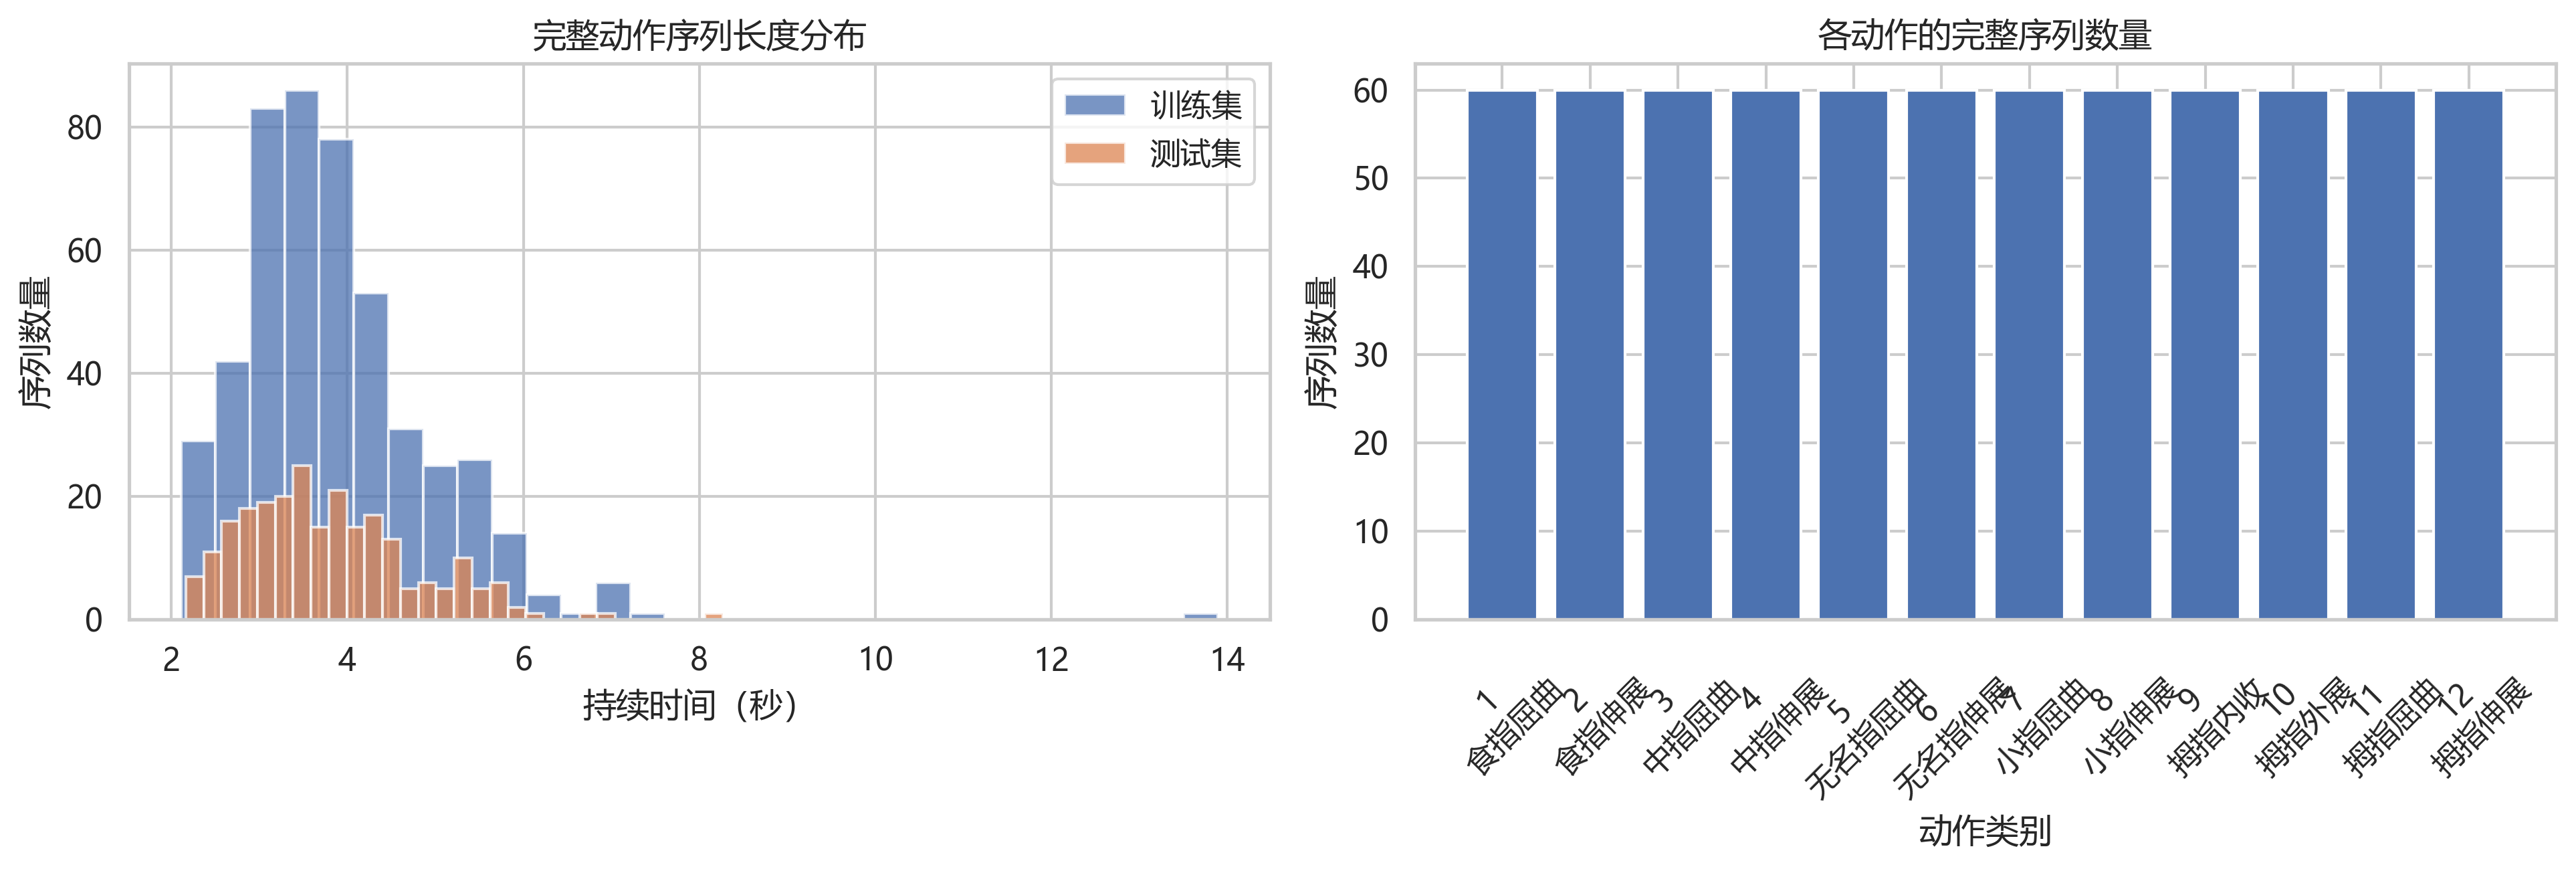

In [5]:
train_lengths = [len(item["X"]) / SAMPLE_RATE for item in sequences if item["repetition"] in TRAIN_REPETITIONS]
test_lengths = [len(item["X"]) / SAMPLE_RATE for item in sequences if item["repetition"] in TEST_REPETITIONS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=300)

axes[0].hist(train_lengths, bins=30, alpha=0.75, label="训练集")
axes[0].hist(test_lengths, bins=30, alpha=0.75, label="测试集")
axes[0].set_title("完整动作序列长度分布")
axes[0].set_xlabel("持续时间（秒）")
axes[0].set_ylabel("序列数量")
axes[0].legend()

class_counts = np.bincount([item["y"] for item in sequences], minlength=12)
axes[1].bar(np.arange(12), class_counts)
axes[1].set_title("各动作的完整序列数量")
axes[1].set_xlabel("动作类别")
axes[1].set_ylabel("序列数量")
axes[1].set_xticks(np.arange(12))
axes[1].set_xticklabels([f"{i + 1}\n{GESTURE_NAMES[i + 1]}" for i in range(12)], rotation=45)

fig.tight_layout()
plt.show()

## 5. 划分并打包变长序列

训练集使用重复 1、3、4、6，测试集使用重复 2、5。单个序列的取法为：

```python
sequence = X[offsets[i]:offsets[i + 1]]  # [时间, 16通道]
```

这种格式完整保留所有时间点，没有截断和补零。

In [6]:
def pack_sequences(items):
    """将变长序列连续保存，并生成每个序列的边界和属性。"""
    sequence_lengths = np.asarray([len(item["X"]) for item in items], dtype=np.int32)
    offsets = np.concatenate([
        np.array([0], dtype=np.int64),
        np.cumsum(sequence_lengths, dtype=np.int64),
    ])

    return {
        "X": np.concatenate([item["X"] for item in items], axis=0).astype(np.float32, copy=False),
        "offsets": offsets,
        "lengths": sequence_lengths,
        "y": np.asarray([item["y"] for item in items], dtype=np.int64),
        "subject": np.asarray([item["subject"] for item in items], dtype=np.int16),
        "repetition": np.asarray([item["repetition"] for item in items], dtype=np.int8),
        "start_sample": np.asarray([item["start_sample"] for item in items], dtype=np.int32),
        "end_sample": np.asarray([item["end_sample"] for item in items], dtype=np.int32),
    }


train_items = [item for item in sequences if item["repetition"] in TRAIN_REPETITIONS]
test_items = [item for item in sequences if item["repetition"] in TEST_REPETITIONS]

datasets = {
    "train": pack_sequences(train_items),
    "test": pack_sequences(test_items),
}

for split, dataset in datasets.items():
    print(
        f"{split:>5}: 序列数={len(dataset['y'])}, "
        f"X={dataset['X'].shape} {dataset['X'].dtype}, "
        f"长度范围={dataset['lengths'].min()}～{dataset['lengths'].max()}, "
        f"重复={sorted(np.unique(dataset['repetition']).tolist())}"
    )

train: 序列数=480, X=(370986, 16) float32, 长度范围=422～2779, 重复=[1, 3, 4, 6]
 test: 序列数=240, X=(182648, 16) float32, 长度范围=433～1653, 重复=[2, 5]


## 6. 保存训练集、测试集和元数据

In [7]:
train_path = OUTPUT_DIR / "train.npz"
test_path = OUTPUT_DIR / "test.npz"
metadata_path = OUTPUT_DIR / "metadata.json"

np.savez_compressed(train_path, **datasets["train"])
np.savez_compressed(test_path, **datasets["test"])

all_lengths = np.asarray([len(item["X"]) for item in sequences])
metadata = {
    "dataset": "NinaPro DB5",
    "exercise": "A / E1",
    "representation": "full_action_variable_length",
    "sample_rate_hz": SAMPLE_RATE,
    "channels": N_CHANNELS,
    "subjects": SUBJECT_IDS,
    "train_repetitions": list(TRAIN_REPETITIONS),
    "test_repetitions": list(TEST_REPETITIONS),
    "rest_included": False,
    "normalized": False,
    "filtered_in_notebook": False,
    "label_field": "restimulus",
    "repetition_field": "rerepetition",
    "storage": {
        "X_layout": "[全部时间点, 16通道]",
        "sequence_i": "X[offsets[i]:offsets[i+1]]",
        "single_sequence_layout": "[时间点, 16通道]",
        "padding": False,
        "truncation": False,
    },
    "sequence_length_samples": {
        "min": int(all_lengths.min()),
        "median": int(np.median(all_lengths)),
        "max": int(all_lengths.max()),
    },
    "label_mapping": {
        str(raw_label - 1): {"raw_label": raw_label, "name_zh": GESTURE_NAMES[raw_label]}
        for raw_label in range(1, 13)
    },
    "outputs": {
        split: {
            "file": f"{split}.npz",
            "sequence_count": int(len(dataset["y"])),
            "X_shape": list(dataset["X"].shape),
            "X_dtype": str(dataset["X"].dtype),
            "length_min": int(dataset["lengths"].min()),
            "length_max": int(dataset["lengths"].max()),
        }
        for split, dataset in datasets.items()
    },
}

with metadata_path.open("w", encoding="utf-8") as file_handle:
    json.dump(metadata, file_handle, ensure_ascii=False, indent=2)

print(f"训练集：{train_path}（{train_path.stat().st_size / 1024**2:.1f} MB）")
print(f"测试集：{test_path}（{test_path.stat().st_size / 1024**2:.1f} MB）")
print(f"元数据：{metadata_path}")

训练集：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\full_sequence\train.npz（6.1 MB）
测试集：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\full_sequence\test.npz（3.0 MB）
元数据：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\ninapro_data\processed\exerciseA\full_sequence\metadata.json


## 7. 重新加载并验证

In [7]:
def validate_dataset(path, allowed_repetitions, expected_count):
    """验证紧凑变长序列文件的结构和内容。"""
    with np.load(path, allow_pickle=False) as loaded:
        data = {name: loaded[name] for name in loaded.files}

    assert data["X"].ndim == 2 and data["X"].shape[1] == N_CHANNELS
    assert data["X"].dtype == np.float32
    assert np.isfinite(data["X"]).all()
    assert len(data["y"]) == expected_count
    assert len(data["offsets"]) == expected_count + 1
    assert data["offsets"][0] == 0 and data["offsets"][-1] == len(data["X"])
    assert np.array_equal(np.diff(data["offsets"]), data["lengths"])
    assert set(np.unique(data["y"])) == set(range(12))
    assert set(np.unique(data["subject"])) == set(SUBJECT_IDS)
    assert set(np.unique(data["repetition"])) == set(allowed_repetitions)
    assert np.array_equal(data["end_sample"] - data["start_sample"], data["lengths"])
    return data


saved_train = validate_dataset(train_path, TRAIN_REPETITIONS, 10 * 12 * 4)
saved_test = validate_dataset(test_path, TEST_REPETITIONS, 10 * 12 * 2)

# 演示取回第一个完整动作，形状为 [时间, 16通道]
first_sequence = saved_train["X"][saved_train["offsets"][0]:saved_train["offsets"][1]]
print("全部验证通过。")
print("第一个完整动作形状：", first_sequence.shape)
print("训练序列数：", len(saved_train["y"]))
print("测试序列数：", len(saved_test["y"]))

全部验证通过。
第一个完整动作形状： (787, 16)
训练序列数： 480
测试序列数： 240


## 8. PyTorch 读取示例

Dataset 返回未补零的完整动作 `[16通道, 时间]`。组成批次时可使用 `pad_sequence` 只补齐到当前批次的最长序列，并保留原始长度供模型生成掩码。

In [8]:
try:
    import torch
    from torch.nn.utils.rnn import pad_sequence
    from torch.utils.data import Dataset

    class FullSequenceDataset(Dataset):
        def __init__(self, npz_path):
            with np.load(npz_path, allow_pickle=False) as loaded:
                self.X = loaded["X"]
                self.offsets = loaded["offsets"]
                self.y = loaded["y"]

        def __len__(self):
            return len(self.y)

        def __getitem__(self, index):
            start, end = self.offsets[index:index + 2]
            sequence = torch.from_numpy(self.X[start:end].copy()).T  # [通道, 时间]
            return sequence, int(self.y[index])

    def collate_full_sequences(batch):
        sequences, labels = zip(*batch)
        lengths = torch.tensor([sequence.shape[1] for sequence in sequences])
        padded = pad_sequence(
            [sequence.T for sequence in sequences],
            batch_first=True,
        ).transpose(1, 2)  # [批次, 通道, 时间]
        return padded, torch.tensor(labels), lengths

    train_dataset = FullSequenceDataset(train_path)
    example_X, example_y = train_dataset[0]
    print("单个完整动作：", tuple(example_X.shape), "标签：", example_y)
except ModuleNotFoundError:
    print("当前环境未安装 PyTorch；NPZ 数据已经准备完成。")

单个完整动作： (16, 787) 标签： 0
